In [ ]:
# Install required libraries
!pip install -q diffusers transformers accelerate safetensors peft datasets


In [ ]:
!git clone https://github.com/huggingface/diffusers.git
%cd diffusers/examples/text_to_image


Cloning into 'diffusers'...
remote: Enumerating objects: 120166, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 120166 (delta 0), reused 1 (delta 0), pack-reused 120163 (from 1)
Receiving objects: 100% (120166/120166), 93.33 MiB | 19.81 MiB/s, done.
Resolving deltas: 100% (89556/89556), done.
/content/diffusers/examples/text_to_image


In [ ]:
import torch
print("GPU:", torch.cuda.get_device_name(0))
print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")

GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json:   0%|          | 0.00/897 [00:00<?, ?B/s]

data/train-00000-of-00002-12944970063701(…):   0%|          | 0.00/344M [00:00<?, ?B/s]

data/train-00001-of-00002-cefa2f480689f1(…):   0%|          | 0.00/357M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1221 [00:00<?, ? examples/s]

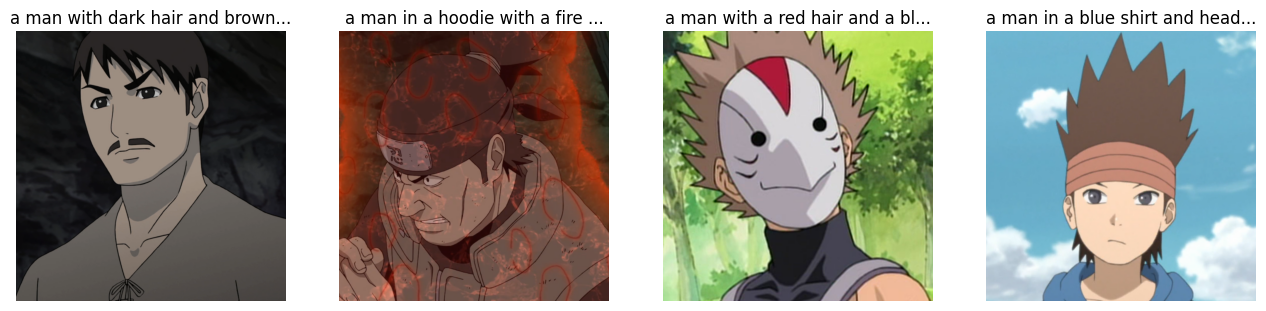

In [ ]:
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset("lambdalabs/naruto-blip-captions", split="train")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    axes[i].imshow(dataset[i]["image"])
    axes[i].set_title(dataset[i]["text"][:30] + "...")
    axes[i].axis("off")
plt.show()

In [ ]:
!accelerate config default

accelerate configuration saved at /root/.cache/huggingface/accelerate/default_config.yaml


In [ ]:
from huggingface_hub import login
login("Enter your token")

In [ ]:
!pip install git+https://github.com/huggingface/diffusers.git
import diffusers
print(diffusers.__version__)

  Cloning https://github.com/huggingface/diffusers.git to /tmp/pip-req-build-r4fb7zqp
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers.git /tmp/pip-req-build-r4fb7zqp
  Resolved https://github.com/huggingface/diffusers.git to commit 71a6fd9f0df04d3764dfa999268a05d87903a85a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.38.0.dev0-py3-none-any.whl size=5166825 sha256=fcd5a0e1adc4028f965577e382a6c272247cb02d06dc61182f13f61fef84afa4
  Stored in directory: /tmp/pip-ephem-wheel-cache-hvzmox50/wheels/23/0f/7d/f97813d265ed0e599a78d83afd4e1925740896ca79b46cccfd
Successfully built diffusers
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.37.1
    Uninstalling diffusers-0.37.1:
      Successfully uninstalled diffusers-0.37.1
0.38.0.dev0


In [ ]:
!accelerate launch train_text_to_image_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --dataset_name="lambdalabs/naruto-blip-captions" \
  --resolution=512 --center_crop --random_flip \
  --train_batch_size=2 \
  --gradient_accumulation_steps=2 \
  --max_train_steps=15000 \
  --learning_rate=1e-04 \
  --lr_scheduler="cosine" \
  --lr_warmup_steps=100 \
  --mixed_precision="fp16" \
  --checkpointing_steps=3000 \
  --output_dir="sd-naruto-lora" \
  --rank=4

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
INFO:__main__:[RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
INFO:httpx:HTTP Request: HEAD https://huggingface.co/runwayml/stable-diffusion-v1-5/resolve/main/scheduler/scheduler_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5/resolve/main/s

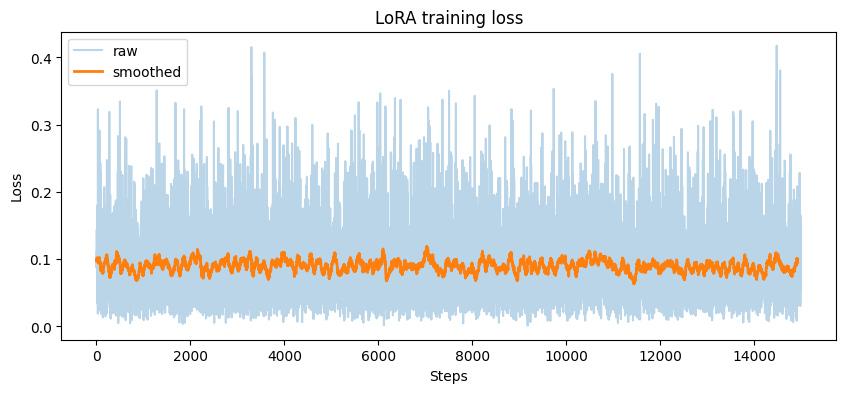

In [ ]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
import numpy as np

log_dir = "sd-naruto-lora/logs/text2image-fine-tune"

ea = event_accumulator.EventAccumulator(log_dir)
ea.Reload()
loss = ea.Scalars("train_loss")

steps  = [x.step  for x in loss]
values = [x.value for x in loss]

# smoothed curve
window   = 50
smoothed = np.convolve(values, np.ones(window) / window, mode="valid")

plt.figure(figsize=(10, 4))
plt.plot(steps, values, alpha=0.3, label="raw")
plt.plot(steps[:len(smoothed)], smoothed, linewidth=2, label="smoothed")
plt.xlabel("Steps"); plt.ylabel("Loss")
plt.title("LoRA training loss"); plt.legend(); plt.show()

In [ ]:
from diffusers import StableDiffusionPipeline
import torch

prompts = [
    "anime character with dark hair, portrait, high quality",
    "anime man in hoodie, fire background, dramatic lighting",
    "red haired anime man wearing black shirt",
    "anime ninja wearing blue shirt and headband",
    "anime character with glasses balancing on one leg"
]
prompts_short = ["Dark hair", "Hoodie+fire", "Red hair", "Blue ninja", "One-leg"]
checkpoint_steps  = [3000, 6000, 9000, 12000]
checkpoint_labels = ["Early (3k)", "Mid-1 (6k)", "Mid-2 (9k)", "Late (12k)"]

generator = torch.Generator("cuda").manual_seed(42)  # fixed seed

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16, safety_checker=None
).to("cuda")

all_images = []
for step in checkpoint_steps:
    pipe.load_lora_weights(f"sd-naruto-lora/checkpoint-{step}")
    row = [pipe(p, num_inference_steps=30, guidance_scale=7.5,
                generator=generator).images[0] for p in prompts]
    all_images.append(row)
    pipe.unload_lora_weights()  # clean up before next checkpoint

fig, axes = plt.subplots(len(checkpoint_steps), len(prompts), figsize=(20, 12))
for i in range(len(checkpoint_steps)):
    for j in range(len(prompts)):
        axes[i, j].imshow(all_images[i][j])
        if i == 0: axes[i, j].set_title(prompts_short[j], fontsize=13)
        axes[i, j].axis("off")
for i, label in enumerate(checkpoint_labels):
    fig.text(0.04, 0.85 - i * (1 / len(checkpoint_steps)), label,
             va="center", ha="right", fontsize=11, fontweight="bold")
plt.tight_layout(rect=[0.08, 0, 1, 1]); plt.show()

Output hidden; open in https://colab.research.google.com to view.

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

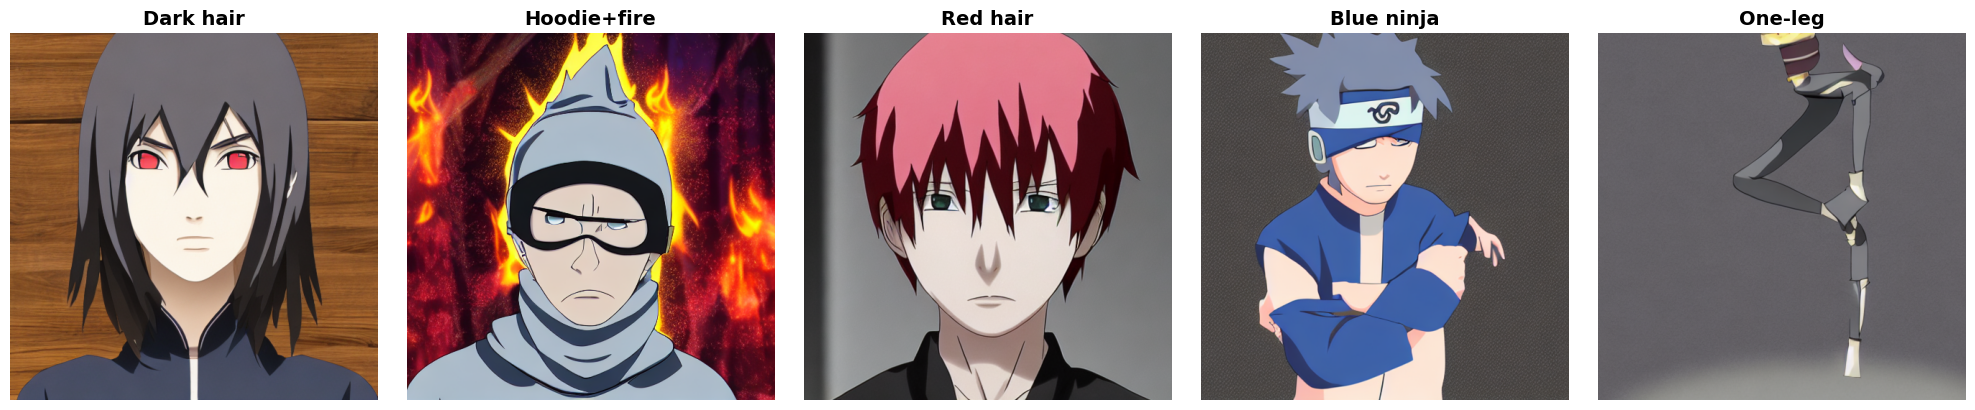

In [ ]:
import os
import matplotlib.pyplot as plt

pipe.load_lora_weights("sd-naruto-lora")  # load final trained weights

generator = torch.Generator("cuda").manual_seed(42)

images = [pipe(p, num_inference_steps=30, guidance_scale=7.5,
               generator=generator).images[0] for p in prompts]

os.makedirs("results", exist_ok=True)

fig, axes = plt.subplots(1, len(images), figsize=(20, 4))
for i, img in enumerate(images):
    axes[i].imshow(img)
    axes[i].set_title(prompts_short[i], fontsize=14, fontweight="bold")
    axes[i].axis("off")
    img.save(f"results/lora_{prompts_short[i].replace(' ', '_')}.png")

plt.tight_layout()
fig.savefig("results/lora_final_grid.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
from google.colab import drive
drive.mount("/content/drive")

!cp -r results       "/content/drive/MyDrive/PartA-results"
print("Saved to Drive")

Mounted at /content/drive
Saved to Drive
